## Baseline models

In [208]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, r2_score)

In [209]:
# load database
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])
print(df.shape)
print(df.columns.tolist())

(62536, 60)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'd

### Train-test split

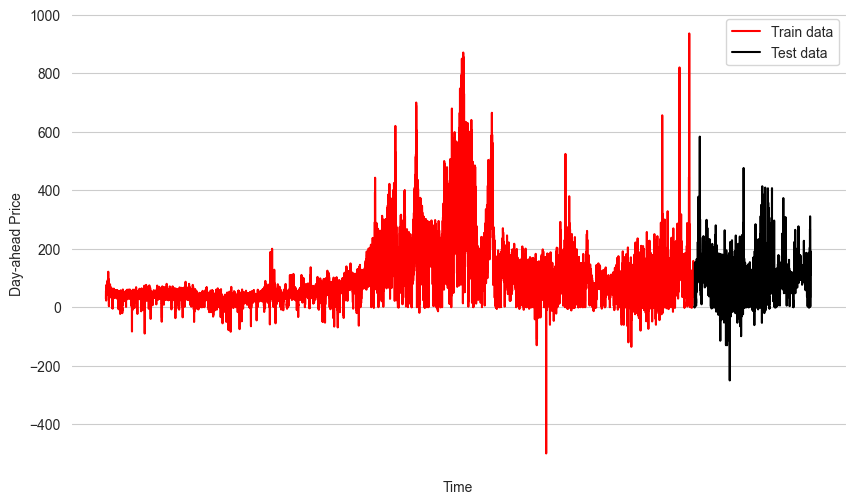

In [210]:
# Split data into train and test sample
test_start = "2025-01-01"

train_df = df[df['timestamp'] < test_start].copy()
test_df  = df[df['timestamp'] >= test_start].copy()

# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price')
plt.xticks([])
plt.plot(train_df['price'], 'red', label='Train data')
plt.plot(test_df['price'], 'black', label='Test data')
plt.legend();

### Naive model (as in Biro et al)

In [211]:
def predict_price_lag(df, price_col='price', day_col='day_of_week'):
    """
    Predict price using a conditional lag:
    - Tue, Wed, Thu, Fri, Sun → lag 1
    - Sat, Mon → lag 7

    Args:
        df: pandas DataFrame with columns price_col and day_col
        price_col: name of the price column
        day_col: name of the day-of-week column (0=Monday,...6=Sunday)
    
    Returns:
        pandas Series with predicted prices
    """
    # Create lag columns
    lag_1 = df[price_col].shift(1)
    lag_7 = df[price_col].shift(7)
    
    # Days mapping: 0=Monday,...6=Sunday
    # Tue=1, Wed=2, Thu=3, Fri=4, Sun=6 → lag_1
    # Sat=5, Mon=0 → lag_7
    lag_1_days = [1,2,3,4,6]
    lag_7_days = [0,5]

    # Apply condition
    predicted = pd.Series(index=df.index, dtype=float)
    predicted[df[day_col].isin(lag_1_days)] = lag_1[df[day_col].isin(lag_1_days)]
    predicted[df[day_col].isin(lag_7_days)] = lag_7[df[day_col].isin(lag_7_days)]

    return predicted

In [212]:
# Predict with the naive model
test_df['price_pred_naive'] = predict_price_lag(test_df)

### Forecast evaluation

In [213]:
# Define metrics

# Mean Absolute Error (MAE)
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Symmetric Mean Absolute Percentage Error (SMAPE)
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

In [214]:
# Daily block evaluation

df_eval = test_df.copy()
df_eval['date'] = df_eval['timestamp'].dt.date

daily_scores = []

for date, group in df_eval.groupby('date'):

    # ensure full 24-hour block
    if len(group) != 24:
        continue

    y_true = group['price'].values
    y_pred = group['price_pred_naive'].values

    daily_scores.append({
        'date': date,
        'MAE': mae(y_true, y_pred),
        'SMAPE': smape(y_true, y_pred)
    })

daily_scores = pd.DataFrame(daily_scores)

In [215]:
daily_scores.head()

,date,MAE,SMAPE
0,2025-01-01,NaN,NaN
1,2025-01-02,10.581667,27.734694
2,2025-01-03,5.913333,6.582941
3,2025-01-04,21.293750,18.728753
4,2025-01-05,6.211250,9.585290


In [216]:
# overall test performance
summary = daily_scores[['MAE','SMAPE']].mean()
print(summary.round(4))

MAE      21.4398
SMAPE    37.1545
dtype: float64


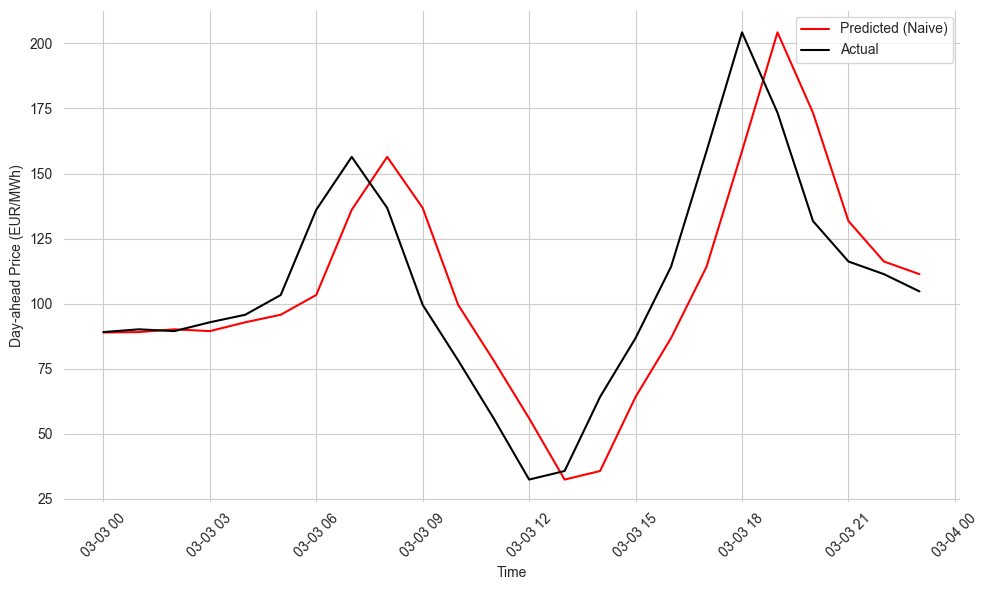

In [217]:
# Plotting true and forecasted for a specific day

day = "2026-03-03"

day_df = test_df[test_df['timestamp'].dt.date == pd.to_datetime(day).date()]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df['timestamp'], day_df['price_pred_naive'],
         color='red', label='Predicted (Naive)')

plt.plot(day_df['timestamp'], day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO

In [218]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

In [219]:
# define additional lagged prices
df['price_lag_48h'] = df['price'].shift(48)
df['price_lag_72h'] = df['price'].shift(72)

# lagged generation
df['generation_48h'] = df['total_generation'].shift(48)
df['generation_72h'] = df['total_generation'].shift(72)
df['generation_168h'] = df['total_generation'].shift(168)

# lagged net export
df['net_export_48h'] = df['net_export'].shift(48)
df['net_export_72h'] = df['net_export'].shift(72)
df['net_export_168h'] = df['net_export'].shift(168)

In [220]:
lag_cols = [
    'price_lag_24h', 'price_lag_48h', 'price_lag_72h', 'price_lag_168h'
]

In [221]:
exog_features = [
    'load', 'wind_offshore', 'wind_onshore', 'solar',
    'net_export_48h', 'net_export_72h', 'net_export_168h',
    'generation_48h', 'generation_72h', 'generation_168h',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

In [222]:
# Split data into train and test sample
test_start = "2025-01-01"

train_df = df[df['timestamp'] < test_start].copy()
test_df  = df[df['timestamp'] >= test_start].copy()

train_df = train_df.dropna().copy()

In [223]:
X_train = train_df[lag_cols + exog_features]
y_train = train_df['price']

X_test = test_df[lag_cols + exog_features]

In [224]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [225]:
lasso = LassoCV(
    cv=5,
    n_alphas=100,
    max_iter=10000,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

LassoCV(cv=5, max_iter=10000, n_jobs=-1)

In [226]:
test_df['price_pred_arxlasso'] = lasso.predict(X_test_scaled)

In [227]:
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_lag_24h      49.995304
price_lag_168h     23.069978
price_lag_72h      13.444235
load               13.334398
net_export_48h      6.922725
price_lag_48h       4.535633
dow_cos             3.174392
hour_cos            1.936807
dow_sin             1.282214
net_export_168h     1.127489
hour_sin            0.760826
month_cos           0.111917
wind_offshore      -6.118971
solar              -6.337159
generation_48h     -6.345788
wind_onshore      -15.304788
dtype: float64


In [228]:
# Daily block evaluation

df_eval = test_df.copy()
df_eval['date'] = df_eval['timestamp'].dt.date

daily_scores = []

for date, group in df_eval.groupby('date'):

    # ensure full 24-hour block
    if len(group) != 24:
        continue

    y_true = group['price'].values
    y_pred = group['price_pred_arxlasso'].values

    daily_scores.append({
        'date': date,
        'MAE': mae(y_true, y_pred),
        'SMAPE': smape(y_true, y_pred)
    })

daily_scores = pd.DataFrame(daily_scores)

In [229]:
# overall test performance
summary = daily_scores[['MAE','SMAPE']].mean()
print(summary.round(4))

MAE      18.8416
SMAPE    36.8886
dtype: float64


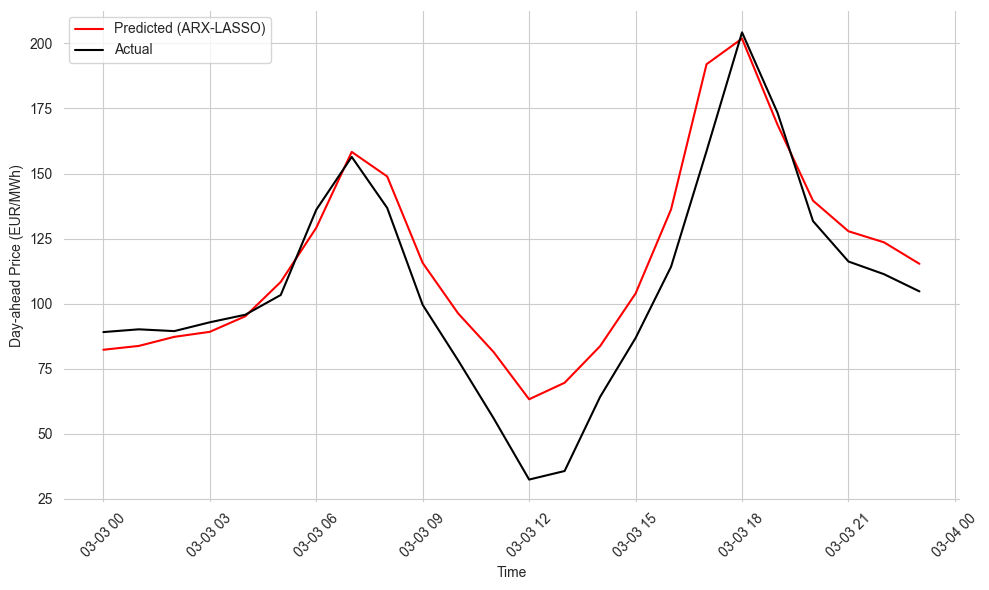

In [230]:
# Plotting true and forecasted for a specific day

day = "2026-03-03"

day_df = test_df[test_df['timestamp'].dt.date == pd.to_datetime(day).date()]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df['timestamp'], day_df['price_pred_arxlasso'],
         color='red', label='Predicted (ARX-LASSO)')

plt.plot(day_df['timestamp'], day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()